## Dynamical Low-Rank Approximation

This notebook tests out the Dynamical Low-Rank Approximation scheme on some simple problems.
This is the non-CG variant, proposed by Schotthöfer et al. "Low-rank lottery tickets: finding efficient low-rank neural networks via matrix differential equations"

The problem with this method is slow convergence. This motivates our proposed method of using conjugate gradient (CG) or preconditioned CG (PCG).

For the implementation, see `src/algorithms/dynamical_low_rank_solver.py`.

---

In [1]:
import matplotlib.pyplot as plt

from fenics import *
from utils.colors import *
from utils.problem_setup import TestProblemsSetup
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W, tikhonov_solver
from algorithms.dynamical_low_rank_solver import DynamicalLowRankSolver

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
setup = TestProblemsSetup(n=64)
problems = setup.get_test_problems()

In [3]:
f_list = []
max_ranks = [1, 2]
for pid, mr in zip(['I', 'II'], max_ranks):
    p = problems[pid]
    rsvd: MatrixFreeRSVD = p['rsvd']
    rsvd.mf_rsvd(k=50)
    w = get_approximate_W(rsvd.VkT.T, rsvd.M_dx)

    # rSVD solution (for comparison)
    f_full_rank = Function(p['V_h'])
    f_full_rank.vector()[:] = tikhonov_solver(rsvd, w, p['y'], lambda_=1e-4)

    # DLR solution
    solver = DynamicalLowRankSolver(p['rsvd'], x_true=p['x'])
    f_dynamical_low_rank = solver.solve(
        p['y'], w,
        lambda_=1e-4,
        max_rank=mr,
        rho=0.0,
        tol=1e-8,
    )
    f_list.extend([f_full_rank, f_dynamical_low_rank])

[##############################] 5000/5000 (diff=1.5e-02)
[##############################] 5000/5000 (diff=6.5e-03)


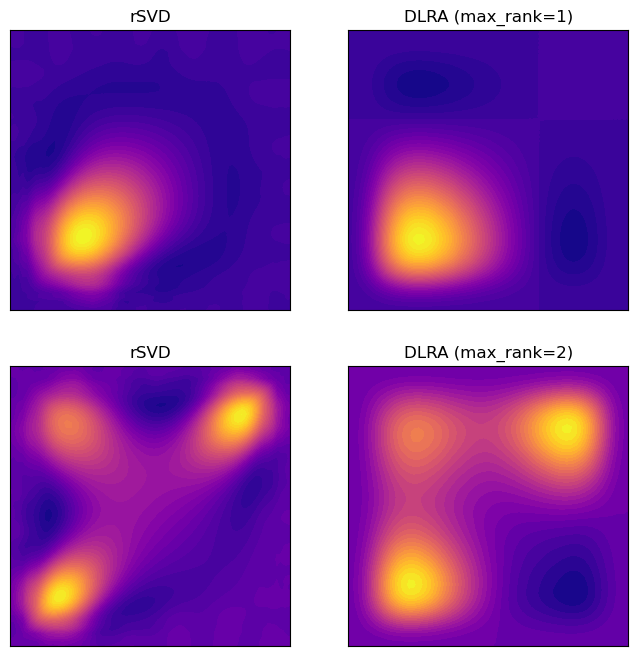

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

titles = ['rSVD', 'DLRA (max_rank=1)', 'rSVD', 'DLRA (max_rank=2)']
for ax, f, t in zip(axes, f_list, titles):
    plt.sca(ax)
    p = plot(f, cmap=CMAP)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(t)